In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Math
import numpy as np

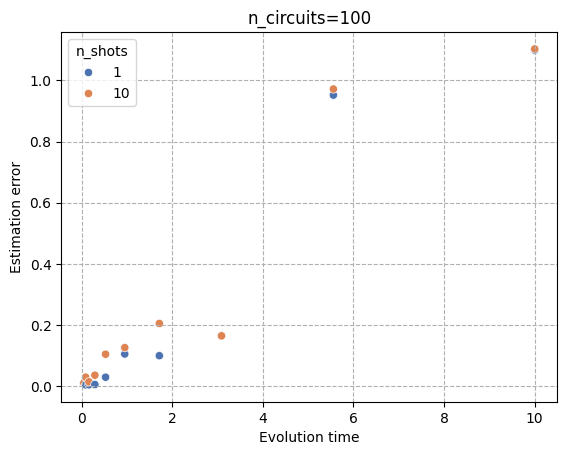

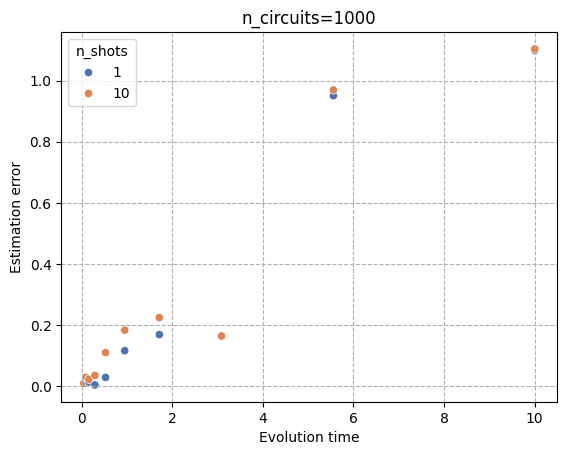

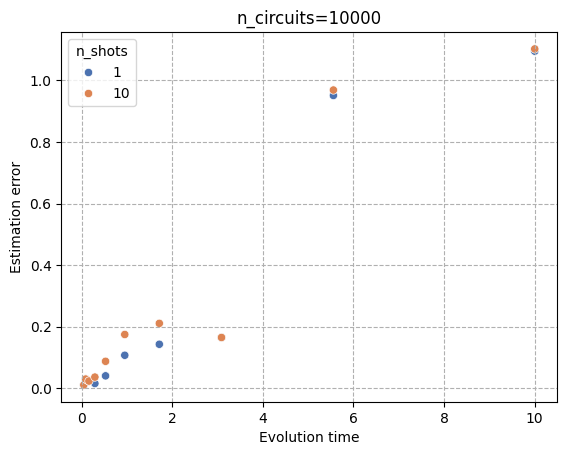

In [11]:
df = pd.read_csv("qdrift_qpe_fc_parameter_sweep_2025-09-20.csv")
times = sorted(df["time"].unique())
df = df[df["time"] > times[1] ]  # filter for specific ancilla count if needed

for groupname, groupdf in df.groupby(["n_circuits"]):
    plt.figure()
    sns.scatterplot(data=groupdf,
                    x="time",
                    y="estimation_error",
                    hue="n_shots",
                    palette="deep")
    plt.title(f"n_circuits={groupname[0]}")
    plt.xlabel("Evolution time")
    plt.ylabel("Estimation error")
    plt.grid(True, which="both", ls="--")
    plt.show()


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Math

def plot_qdrift_results(df: pd.DataFrame, loglog: bool = True) -> None:
    # -------------------------------------------------------------------------
    # Load and preprocess
    # -------------------------------------------------------------------------
    times = sorted(df["time"].unique())
    df = df[df["time"] > times[1]]  # filter out first point if needed

    n_circuits = sorted(df["n_circuits"].unique())
    n_shots = sorted(df["n_shots"].unique())

    nrows, ncols = len(n_circuits), len(n_shots)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(4*ncols, 3.5*nrows), sharex=True, sharey=True
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = axes[np.newaxis, :]
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    # -------------------------------------------------------------------------
    # Main plotting loop
    # -------------------------------------------------------------------------
    for i, circ in enumerate(n_circuits):
        for j, shots in enumerate(n_shots):
            ax = axes[i, j]
            subset = df[(df["n_circuits"] == circ) & (df["n_shots"] == shots)]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.scatterplot(
                data=subset, x="time", y="estimation_error",
                ax=ax, s=40, color="C0", alpha=0.7
            )

            if loglog:
                ax.set_xscale("log")
                ax.set_yscale("log")

            # regression fit
            if len(subset) > 1:
                x_log = np.log10(subset["time"])
                y_log = np.log10(subset["error_according_to_mean"])
                coeffs = np.polyfit(x_log, y_log, 1)
                poly_eqn = np.poly1d(coeffs)
                r2 = np.corrcoef(x_log, y_log)[0, 1] ** 2

                x_vals = np.logspace(np.log10(subset["time"].min()), 
                                     np.log10(subset["time"].max()), 100)
                y_vals = 10 ** poly_eqn(np.log10(x_vals))
                ax.plot(x_vals, y_vals, color="gray", linestyle="--")

                display(Math(
                    f"\\text{{Fit for }} n_{{circuits}}={circ},\\; n_{{shots}}={shots}:"
                    f"\\; y={coeffs[0]:.2f}x + {coeffs[1]:.2f},\\; R^2={r2:.2f}"
                ))

            # titles & labels
            ax.set_title(f"n_circuits={circ}, n_shots={shots}")
            if i == nrows - 1:
                ax.set_xlabel("Evolution time")
            if j == 0:
                ax.set_ylabel("Estimation error")

            ax.grid(True, which="both", ls="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


In [16]:

df["error_according_to_mean"] = abs(df["est_energy_mean"] - df["exact_eig"])
df


,ham,exact_eig,num_system_qubits,num_ancilla,alpha,replication_seed,n_circuits,n_shots,time,segments,...,est_energy_med,est_energy_mean,est_energy_std,estimation_error,max_theoretical_qdrift_error,peak_MB,runtime,top10_py_allocs,counts,error_according_to_mean
4,1 qubit test,0.838516,1,10,1.0,42,100,1,0.050586,1,...,0.849070,0.881820,0.413067,0.010553,1.119447e-01,1860.894531,250.901872,NaN,"{""0000000000"": 1, ""0000000110"": 7, ""0000000111...",0.043303
5,1 qubit test,0.838516,1,10,1.0,42,100,10,0.050586,1,...,0.849070,0.851496,0.016981,0.010553,1.119447e-01,1875.019531,257.221014,NaN,"{""0000000111"": 98, ""0000001000"": 2}",0.012979
9,1 qubit test,0.838516,1,10,1.0,42,100,1,0.091021,1,...,0.842652,0.930287,0.386784,0.004135,2.183895e-01,1899.539062,254.408234,NaN,"{""0000000110"": 1, ""0000000111"": 1, ""0000001001...",0.091771
10,1 qubit test,0.838516,1,10,1.0,42,100,10,0.091021,1,...,0.808946,0.829843,0.040103,0.029571,2.183895e-01,1925.417969,260.776588,NaN,"{""0000001010"": 1, ""0000001011"": 1, ""0000001100...",0.008673
12,1 qubit test,0.838516,1,10,1.0,42,1000,1,0.050586,1,...,0.849070,0.664700,1.663696,0.010553,1.119447e-01,2322.640625,2564.606013,NaN,"{""0000000000"": 1, ""0000000011"": 1, ""0000000100...",0.173816
13,1 qubit test,0.838516,1,10,1.0,42,100,1,0.163776,1,...,0.842972,0.906289,1.052595,0.004456,4.544988e-01,2076.675781,256.864063,NaN,"{""0000000000"": 1, ""0000000100"": 1, ""0000000110...",0.067772
14,1 qubit test,0.838516,1,10,1.0,42,100,10,0.163776,1,...,0.824240,0.856085,0.057158,0.014277,4.544988e-01,2027.777344,264.067167,NaN,"{""0000010100"": 1, ""0000010101"": 9, ""0000010110...",0.017569
15,1 qubit test,0.838516,1,10,1.0,42,1000,10,0.050586,1,...,0.849070,0.846644,0.024138,0.010553,1.119447e-01,2342.734375,2622.142497,NaN,"{""0000000110"": 3, ""0000000111"": 96, ""000000100...",0.008127
16,1 qubit test,0.838516,1,10,1.0,42,100,1,0.294684,1,...,0.832882,0.531171,1.730237,0.005634,1.062541e+00,2135.519531,261.523339,NaN,"{""0000000100"": 1, ""0000000101"": 1, ""0000000110...",0.307346
17,1 qubit test,0.838516,1,10,1.0,42,100,10,0.294684,1,...,0.874526,0.808104,1.116721,0.036010,1.062541e+00,2270.050781,264.263211,NaN,"{""0000100000"": 1, ""0000100001"": 1, ""0000100010...",0.030413


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

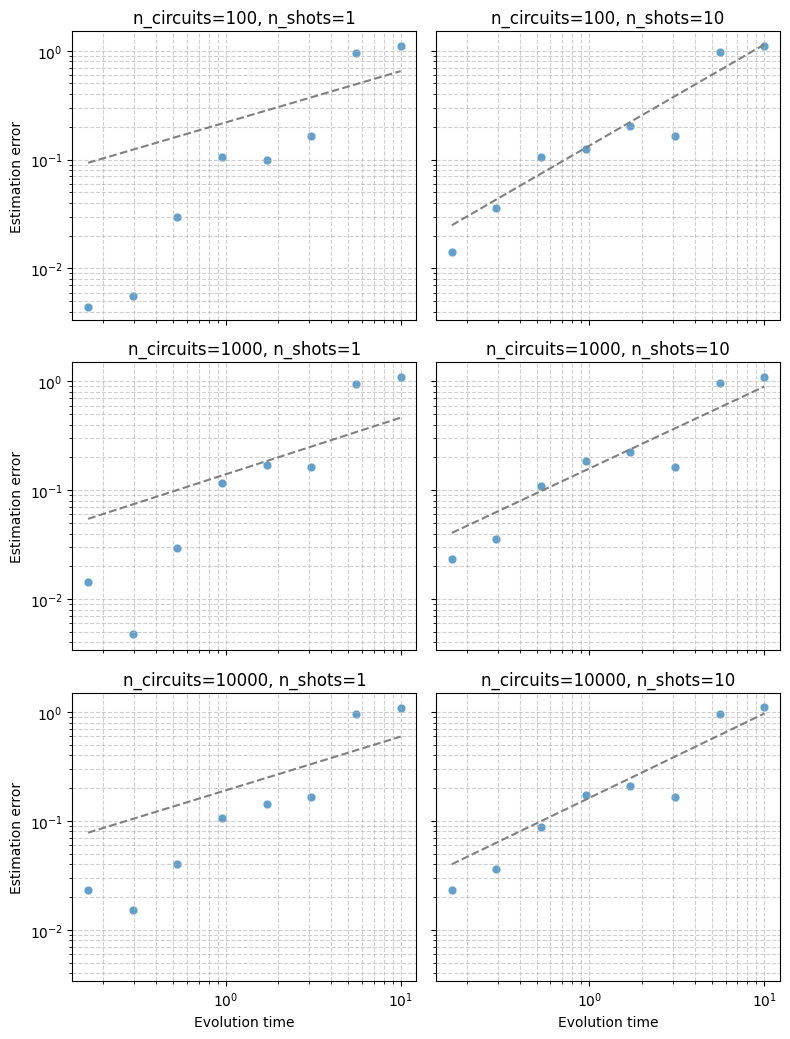

In [17]:
plot_qdrift_results(df)